<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/LSTM_Basic_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf.__version__)


2.19.0


In [2]:
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#data generation
series = np.sin(0.1*np.arange(200)) #+np.random.randn(200)*0.1

<function matplotlib.pyplot.show(close=None, block=None)>

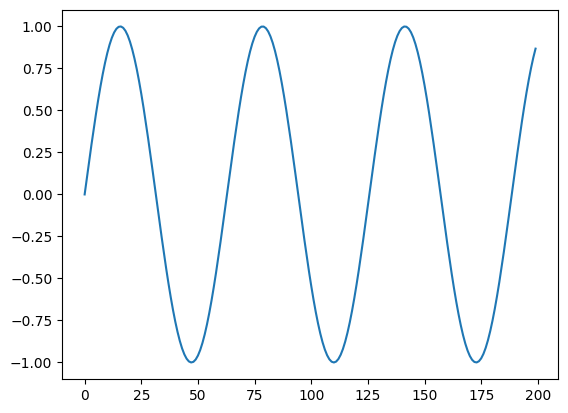

In [4]:
plt.plot(series)
plt.show

In [5]:
#built dataset
#let see if we can use T past values to predict the next values
T=10
D=1
X=[]
Y=[]

for t in range(len(series)-T):
    x=series[t:t+T]
    X.append(x)
    y=series[t+T]
    Y.append(y)

X = np.array(X).reshape(-1, T, D)
Y = np.array(Y)
N=len(X)
print("X.shape", X.shape, "Y.hape", Y.shape)

X.shape (190, 10, 1) Y.hape (190,)


#Activation Relu

In [6]:
#try autoregressive RNN model
i = Input(shape=(T,1))
x = SimpleRNN(5, activation='relu')(i)
x = Dense(1)(x)
model = Model(i,x)

In [7]:
model.compile(loss='mse', optimizer=Adam(learning_rate=0.1))

In [8]:
#train
r=model.fit(
    X[:-N//2], Y[:-N//2], epochs=80,
    validation_data=(X[-N//2:], Y[-N//2:]))

Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - loss: 0.2190 - val_loss: 0.1436
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1314 - val_loss: 0.0416
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0241 - val_loss: 0.0288
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0443 - val_loss: 0.0394
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0378 - val_loss: 0.0131
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0146 - val_loss: 0.0170
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0281 - val_loss: 0.0128
Epoch 8/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0165 - val_loss: 0.0070
Epoch 9/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0088 - val_loss: 0.0063
Epoch 10/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0095 - val_loss: 0.0070
Epoch 11/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0072 - val_loss: 0.0041
Epoch 12/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0041 - val_loss: 0.0031


#Activation Default

In [9]:
#try autoregressive RNN model
i = Input(shape=(T,1))
x = SimpleRNN(5)(i)
x = Dense(1)(x)
model = Model(i,x)

In [10]:
model.compile(loss='mse', optimizer=Adam(learning_rate=0.1))

In [11]:
#train
r=model.fit(
    X[:-N//2], Y[:-N//2], epochs=80,
    validation_data=(X[-N//2:], Y[-N//2:]))

Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - loss: 1.2877 - val_loss: 0.2076
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2258 - val_loss: 0.1896
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2213 - val_loss: 0.1014
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0695 - val_loss: 0.0349
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0340 - val_loss: 0.0618
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0412 - val_loss: 0.0398
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0202 - val_loss: 0.0102
Epoch 8/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0093 - val_loss: 0.0113
Epoch 9/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0098 - val_loss: 0.0149
Epoch 10/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0116 - val_loss: 0.0173
Epoch 11/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0119 - val_loss: 0.0058
Epoch 12/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0040 - val_loss: 0.0032


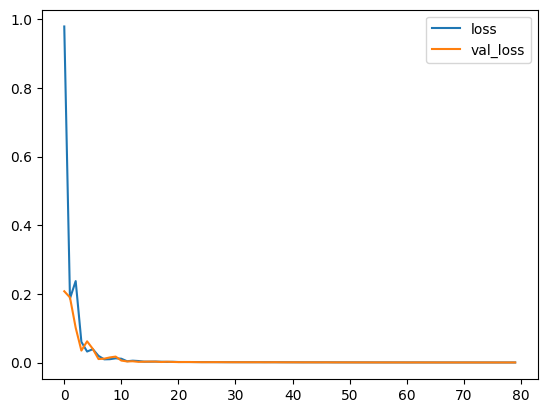

In [12]:
#Plot a loss
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

In [13]:
#Wrong forecast using true targets
validation_target = Y[-N//2:]
validation_predictions = []
#index of firt validation input
i=-N//2

while len(validation_predictions) < len(validation_target):
    p = model.predict(X[i].reshape(1,-1,1))[0,0]
    i+=1
    validation_predictions.append(p)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━

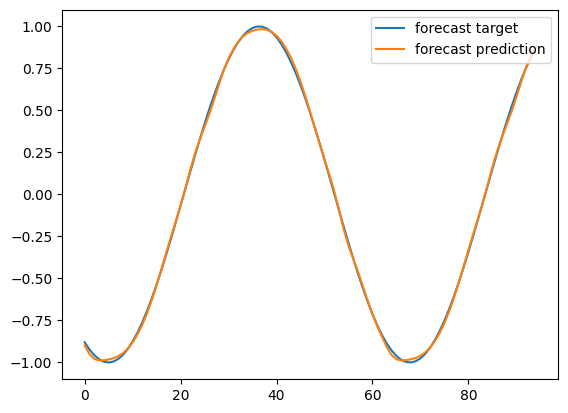

In [14]:
plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()

#Real forecast

In [15]:
#Real forecast using true targets
validation_target = Y[-N//2:]
validation_predictions = []
#last train input
last_x = X[-N//2] #1-D array of lenght T



while len(validation_predictions) < len(validation_target):
    p = model.predict(last_x.reshape(1,-1,1))[0,0]
    #update the sequence
    validation_predictions.append(p)
    #make a new point
    last_x = np.roll(last_x, -1)
    last_x[-1] = p
   # i+=1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

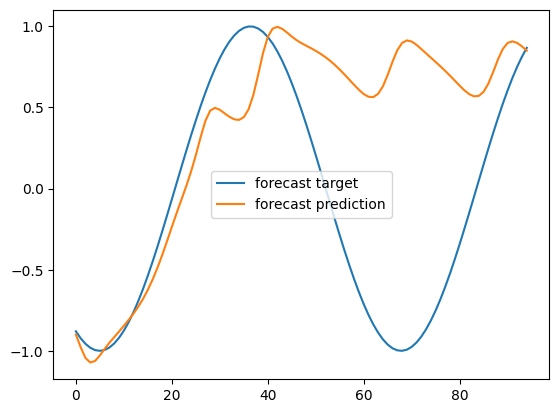

In [16]:
plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()

#Actiavtion None

In [17]:
#try autoregressive RNN model
i = Input(shape=(T,1))
x = SimpleRNN(5, activation=None)(i)
x = Dense(1)(x)
model = Model(i,x)

In [18]:
model.compile(loss='mse', optimizer=Adam(learning_rate=0.1))

In [19]:
#train
r=model.fit(
    X[:-N//2], Y[:-N//2], epochs=80,
    validation_data=(X[-N//2:], Y[-N//2:]))

Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - loss: 3.0479 - val_loss: 0.4342
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3288 - val_loss: 0.1686
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1876 - val_loss: 0.0930
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1072 - val_loss: 0.2736
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1254 - val_loss: 0.0920
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1116 - val_loss: 0.1550
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0841 - val_loss: 0.0376
Epoch 8/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0214 - val_loss: 0.0224
Epoch 9/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0231 - val_loss: 0.0208
Epoch 10/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0180 - val_loss: 0.0147
Epoch 11/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0141 - val_loss: 0.0081
Epoch 12/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0070 - val_loss: 0.0022


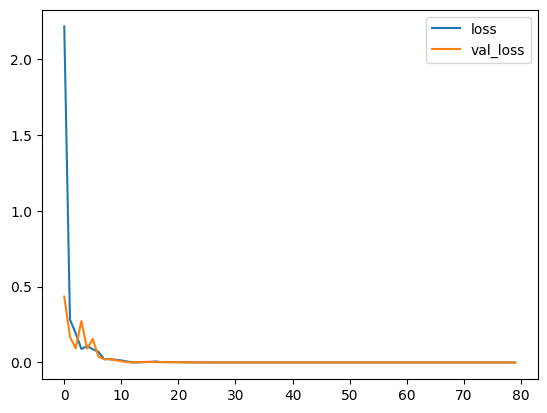

In [20]:
#Plot a loss
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

In [21]:
#Wrong forecast using true targets
validation_target = Y[-N//2:]
validation_predictions = []
#index of firt validation input
i=-N//2

while len(validation_predictions) < len(validation_target):
    p = model.predict(X[i].reshape(1,-1,1))[0,0]
    i+=1 #one step forecast
    validation_predictions.append(p)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━

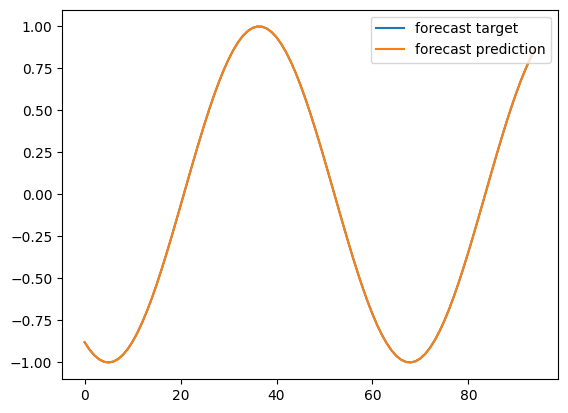

In [22]:
plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()

In [23]:
#multistep forecast
validation_target = Y[-N//2:]
validation_predictions = []

#last train input
last_x = X[-N//2] #1-D array of lenght T

while len(validation_predictions) < len(validation_target):
  p=model.predict(last_x.reshape(1,-1,1))[0,0] #1x1 array scalar
  validation_predictions.append(p)
  last_x=np.roll(last_x,-1)
  last_x[-1]=p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

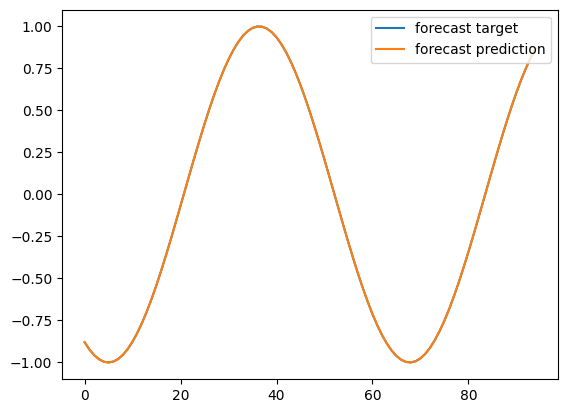

In [24]:
plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()

# With Noise

In [25]:
#data generation
series = np.sin(0.1*np.arange(200)) +np.random.randn(200)*0.1

<function matplotlib.pyplot.show(close=None, block=None)>

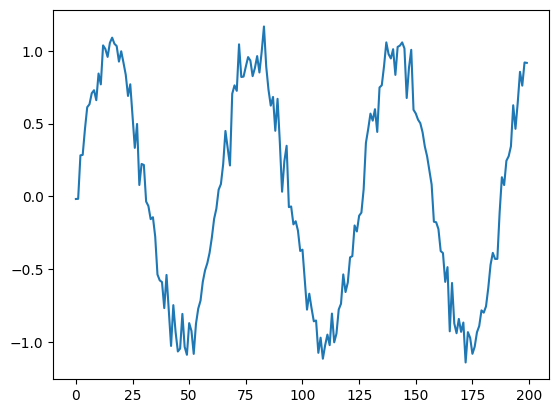

In [26]:
plt.plot(series)
plt.show

In [27]:
#built dataset
#let see if we can use T past values to predict the next values
T=10
D=1
X=[]
Y=[]

for t in range(len(series)-T):
    x=series[t:t+T]
    X.append(x)
    y=series[t+T]
    Y.append(y)

X = np.array(X).reshape(-1, T, D)
Y = np.array(Y)
N=len(X)
print("X.shape", X.shape, "Y.hape", Y.shape)

X.shape (190, 10, 1) Y.hape (190,)


In [28]:
#try autoregressive RNN model
i = Input(shape=(T,1))
x = SimpleRNN(5, activation='relu')(i)
x = Dense(1)(x)
model = Model(i,x)

In [29]:
model.compile(loss='mse', optimizer=Adam(learning_rate=0.1))

In [30]:
#train
r=model.fit(
    X[:-N//2], Y[:-N//2], epochs=80,
    validation_data=(X[-N//2:], Y[-N//2:]))

Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - loss: 0.6730 - val_loss: 0.4051
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.2778 - val_loss: 0.2267
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1219 - val_loss: 0.1359
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0969 - val_loss: 0.0920
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0830 - val_loss: 0.0923
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0812 - val_loss: 0.0770
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0720 - val_loss: 0.0621
Epoch 8/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0500 - val_loss: 0.0314
Epoch 9/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0296 - val_loss: 0.0279
Epoch 10/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0307 - val_loss: 0.0325
Epoch 11/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0334 - val_loss: 0.0292
Epoch 12/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0322 - val_loss: 0.0275


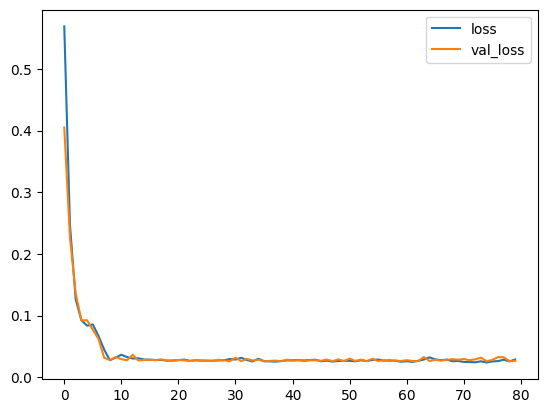

In [31]:
#Plot a loss
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

In [32]:
# 1 step forecast
#Wrong forecast using true targets
validation_target = Y[-N//2:]
validation_predictions = []
#index of firt validation input
i=-N//2

while len(validation_predictions) < len(validation_target):
    p = model.predict(X[i].reshape(1,-1,1))[0,0]
    i+=1
    validation_predictions.append(p)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━

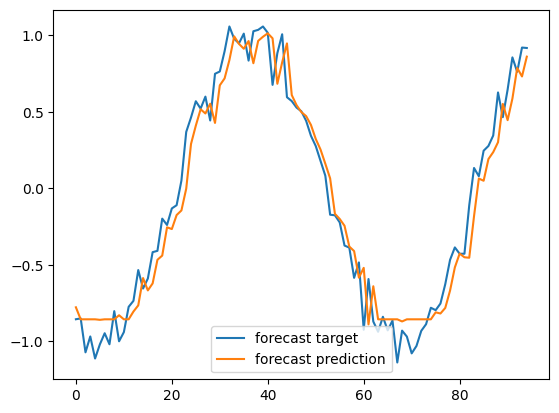

In [33]:
plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()

In [34]:
#multistep forecast
validation_target = Y[-N//2:]
validation_predictions = []
#index of firt validation input
last_x= X[N//2] #1-D array of lenght T

while len(validation_predictions) < len(validation_target):
    p = model.predict(last_x.reshape(1,-1,1))[0,0]
    validation_predictions.append(p)
    last_x=np.roll(last_x,-1)
    last_x[-1]=p


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━

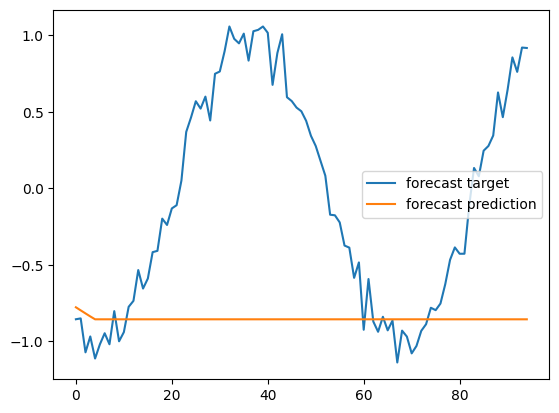

In [35]:
plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()